<a href="https://colab.research.google.com/github/NooraZhang/IBD-diet-and-inflammation-analysis/blob/main/IBDMDB_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import the file


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hmp2_metadata_2018-08-20.csv to hmp2_metadata_2018-08-20.csv


In [ ]:
import pandas as pd
df = pd.read_csv('hmp2_metadata_2018-08-20.csv', low_memory=False)
print(df.shape)

(5533, 490)


# Eliminate the unuseful variables

In [ ]:
import pandas as pd

df = pd.read_csv('hmp2_metadata_2018-08-20.csv', low_memory=False)

columns_to_keep = [
    'Participant ID', 'week_num', 'diagnosis', 'sex', 'race', 'BMI',
    'Age at diagnosis', 'Antibiotics',
    'Immunosuppressants (e.g. oral corticosteroids)',
    'fecalcal_ng_ml', 'fecalcal', 'is_inflamed', 'hbi', 'sccai',
    'CRP (mg/L)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df = df[columns_to_keep]
print(df.shape)
print(df.head())

(5533, 31)
  Participant ID  week_num diagnosis     sex   race  BMI  Age at diagnosis  \
0          C3001       2.0        CD  Female  White  NaN              28.0   
1          C3001       2.0        CD  Female  White  NaN              28.0   
2          C3002       0.0        CD  Female  White  NaN              47.0   
3          C3002       0.0        CD  Female  White  NaN              47.0   
4          C3002       0.0        CD  Female  White  NaN              47.0   

  Antibiotics Immunosuppressants (e.g. oral corticosteroids)  fecalcal_ng_ml  \
0          No                                             No             NaN   
1          No                                             No             NaN   
2          No                                             No             NaN   
3          No                                             No             NaN   
4          No                                             No             NaN   

   ...  \
0  ...   
1  ...   
2  ...   

# Filter out the samples with no data of fecal calprotectin


In [ ]:
inflammation_vars = ['fecalcal', 'fecalcal_ng_ml', 'is_inflamed', 'hbi', 'sccai', 'CRP (mg/L)']

for var in inflammation_vars:
    total = len(df)
    missing = df[var].isna().sum()
    valid = total - missing
    pct_missing = missing/total*100
    print(f"{var}: {valid} valid ({pct_missing:.1f}% missing)")

fecalcal: 1883 valid (66.0% missing)
fecalcal_ng_ml: 121 valid (97.8% missing)
is_inflamed: 881 valid (84.1% missing)
hbi: 2145 valid (61.2% missing)
sccai: 1335 valid (75.9% missing)
CRP (mg/L): 669 valid (87.9% missing)


In [ ]:
# 重新从原始df开始，用fecalcal过滤
df_clean2 = df[df['fecalcal'].notna()]
print(df_clean2.shape)
print(df_clean2['diagnosis'].value_counts())
print(df_clean2['fecalcal'].head(10))

(1883, 31)
diagnosis
CD        928
UC        512
nonIBD    443
Name: count, dtype: int64
522    193.89000
523     61.34000
524    115.27000
525     23.20350
526     37.17836
527     48.90000
528    179.22000
529     54.33000
530     15.97901
531     14.51068
Name: fecalcal, dtype: float64


# Print the number of missing data for each variable

In [ ]:
# 用fecalcal过滤
df_clean = df[df['fecalcal'].notna()].copy()

# 检查missing values
print(df_clean.isnull().sum())

Participant ID                                                                         0
week_num                                                                               0
diagnosis                                                                              0
sex                                                                                    0
race                                                                                   0
BMI                                                                                 1883
Age at diagnosis                                                                     458
Antibiotics                                                                            0
Immunosuppressants (e.g. oral corticosteroids)                                         0
fecalcal_ng_ml                                                                      1883
fecalcal                                                                               0
is_inflamed          

# Delete the variables with no data


In [ ]:
# 删掉全部缺失的列
df_clean = df_clean.drop(columns=['BMI', 'fecalcal_ng_ml', 'is_inflamed', 'CRP (mg/L)'])

# 删掉饮食变量有缺失的行
dietary_cols = [
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Red meat (beef, hamburger, pork, lamb)',
    'White meat (chicken, turkey, etc.)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Water',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

df_clean = df_clean.dropna(subset=dietary_cols)
print(df_clean.shape)
print(df_clean['diagnosis'].value_counts())

(1739, 27)
diagnosis
CD        858
UC        468
nonIBD    413
Name: count, dtype: int64


# Visualization of the distribution of fecalcal

count    1739.000000
mean      116.573963
std       115.177453
min         3.450000
25%        16.733720
50%        54.740000
75%       212.670000
max       493.700000
Name: fecalcal, dtype: float64


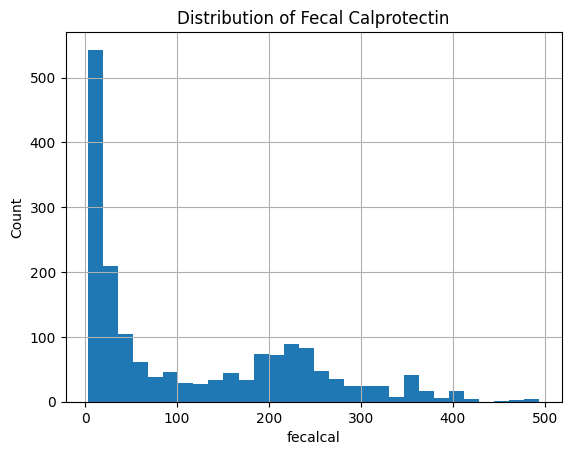

In [ ]:
# 检查fecalcal的分布和outliers
print(df_clean['fecalcal'].describe())

import matplotlib.pyplot as plt
df_clean['fecalcal'].hist(bins=30)
plt.title('Distribution of Fecal Calprotectin')
plt.xlabel('fecalcal')
plt.ylabel('Count')
plt.show()

# Log-transformed visualization of the distribution of fecalcal

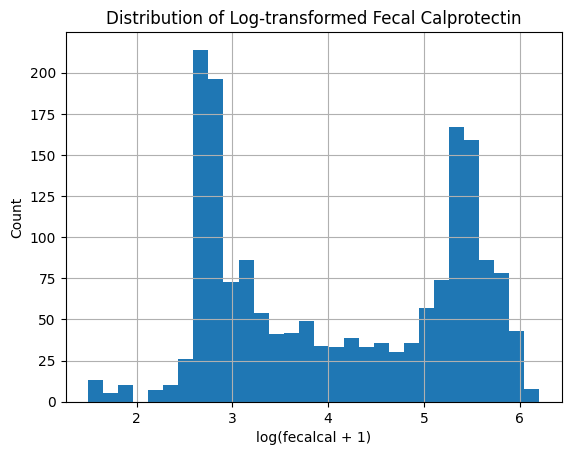

In [ ]:
import numpy as np

# Log transformation
df_clean['fecalcal_log'] = np.log(df_clean['fecalcal'] + 1)

# 看看transformation之后的分布
df_clean['fecalcal_log'].hist(bins=30)
plt.title('Distribution of Log-transformed Fecal Calprotectin')
plt.xlabel('log(fecalcal + 1)')
plt.ylabel('Count')
plt.show()

# Group the samples into high inflammation level and low inflammation level

In [ ]:
# 用50 ng/mL作为分界线（医学上的正常上限）
df_clean['inflammation_group'] = df_clean['fecalcal'].apply(
    lambda x: 'High' if x >= 50 else 'Low'
)

print(df_clean['inflammation_group'].value_counts())

inflammation_group
High    897
Low     842
Name: count, dtype: int64


#visualization of the level of inflammation of IBD and non-IBD participants

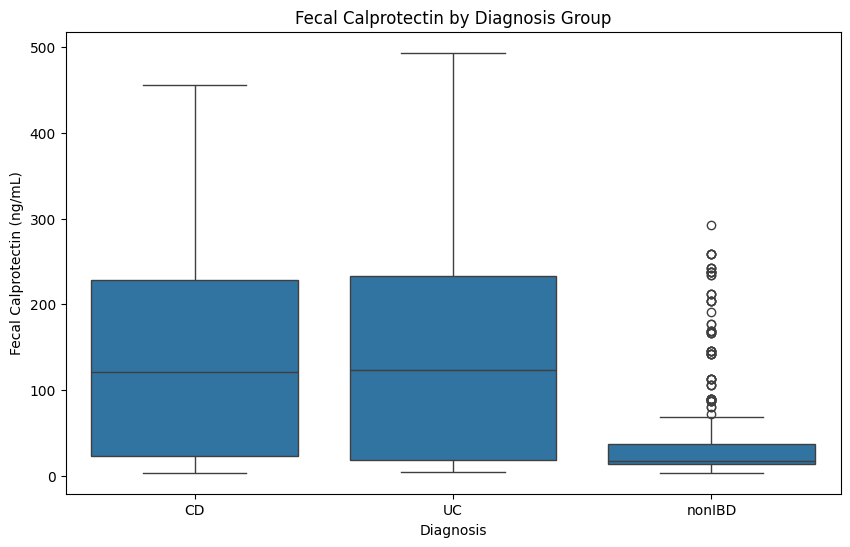

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='diagnosis', y='fecalcal', data=df_clean)
plt.title('Fecal Calprotectin by Diagnosis Group')
plt.xlabel('Diagnosis')
plt.ylabel('Fecal Calprotectin (ng/mL)')
plt.show()

#Result of the Spearman statistical test

---



In [ ]:
from scipy.stats import spearmanr
import pandas as pd

dietary_cols = [
    'Red meat (beef, hamburger, pork, lamb)',
    'Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)',
    'Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)',
    'Fruits (no juice) (Apples, raisins, bananas, oranges, strawberries, blueberries',
    'Whole grains (wheat, oats, brown rice, rye, quinoa, wheat bread, wheat pasta)',
    'Sweets (pies, jam, chocolate, cake, cookies, etc.)',
    'Alcohol (beer, brandy, spirits, hard liquor, wine, aperitif, etc.)',
    'Processed meat (other red or white meat such as lunch meat, ham, salami, bologna',
    'Dairy (milk, cream, ice cream, cheese, cream cheese)',
    'Beans (tofu, soy, soy burgers, lentils, Mexican beans, lima beans etc)',
    'Eggs',
    'Water',
    'Starch (white rice, bread, pizza, potatoes, yams, cereals, pancakes, etc.)',
    'Yogurt or other foods containing active bacterial cultures (kefir, sauerkraut)',
    'White meat (chicken, turkey, etc.)',
    'Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)'
]

results = []
for col in dietary_cols:
    corr, pval = spearmanr(df_clean[col], df_clean['fecalcal'])
    results.append({
        'Food': col,
        'Correlation': round(corr, 3),
        'P-value': round(pval, 4),
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Correlation', ascending=False)
print(results_df.to_string())

                                                                                Food  Correlation  P-value Significant
7   Processed meat (other red or white meat such as lunch meat, ham, salami, bologna        0.088   0.0003         Yes
15  Soft drinks, tea or coffee with sugar (corn syrup, maple syrup, cane sugar, etc)        0.028   0.2416          No
10                                                                              Eggs        0.021   0.3712          No
8                               Dairy (milk, cream, ice cream, cheese, cream cheese)       -0.004   0.8766          No
1                  Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)       -0.037   0.1265          No
14                                                White meat (chicken, turkey, etc.)       -0.042   0.0774          No
5                                 Sweets (pies, jam, chocolate, cake, cookies, etc.)       -0.054   0.0233         Yes
4      Whole grains (wheat, oats, brown rice, ry

# Visualization of the result of the Spearman test

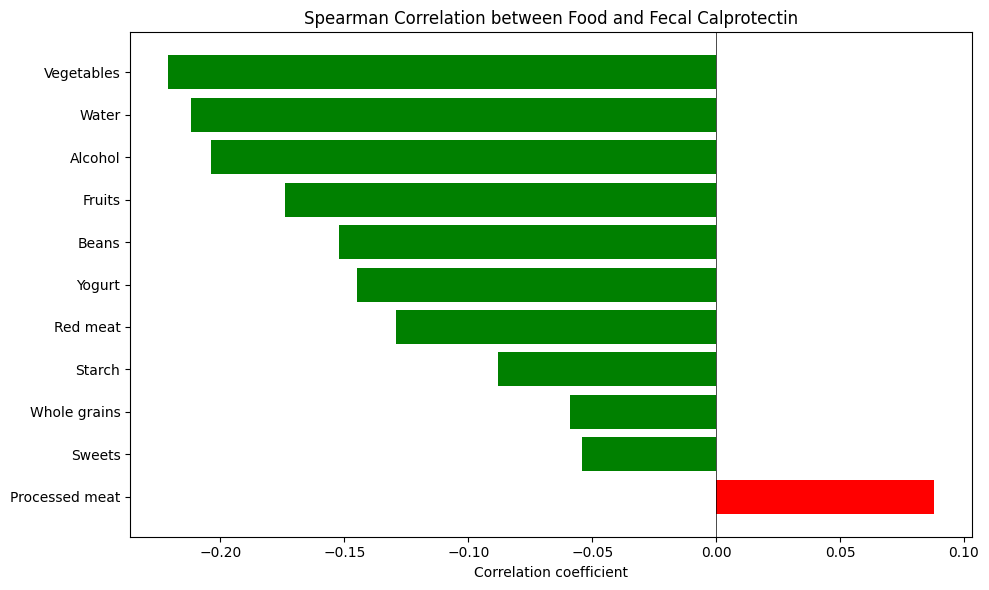

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 只保留显著的结果
sig_results = results_df[results_df['Significant'] == 'Yes'].copy()

# 简化食物名字
sig_results['Food_short'] = [
    'Processed meat', 'Sweets', 'Whole grains', 'Starch',
    'Red meat', 'Yogurt', 'Beans', 'Fruits', 'Alcohol', 'Water', 'Vegetables'
]

plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in sig_results['Correlation']]
plt.barh(sig_results['Food_short'], sig_results['Correlation'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('Spearman Correlation between Food and Fecal Calprotectin')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

In [ ]:
# 把频率文字转成数字
frequency_map = {
    'No, I did not consume these products in the last 7 days': 0,
    'Within the past 4 to 7 days': 1,
    'Within the past 2 to 3 days': 2,
    'Yesterday, 1 to 2 times': 3,
    'Yesterday, 3 or more times': 4
}

for col in dietary_cols:
    df_clean[col] = df_clean[col].map(frequency_map)

print(df_clean[dietary_cols].head())
print(df_clean[dietary_cols].dtypes)

     Red meat (beef, hamburger, pork, lamb)  \
522                                       0   
523                                       0   
524                                       0   
525                                       0   
526                                       0   

     Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)  \
522                                                  2                   
523                                                  1                   
524                                                  1                   
525                                                  1                   
526                                                  1                   

     Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
522                                                  2                                  
523                                                  2                                  
524  

In [ ]:
diet_by_inflammation = df_clean.groupby('inflammation_group')[dietary_cols].mean().round(2)
print(diet_by_inflammation)

                    Red meat (beef, hamburger, pork, lamb)  \
inflammation_group                                           
High                                                  1.55   
Low                                                   1.83   

                    Fish (fish nuggets, breaded fish, fish cakes, salmon, tuna, etc.)  \
inflammation_group                                                                      
High                                                             0.74                   
Low                                                              0.73                   

                    Vegetables (salad, tomatoes, onions, greens, carrots, peppers, green beans, etc)  \
inflammation_group                                                                                     
High                                                             2.34                                  
Low                                                              2.81             

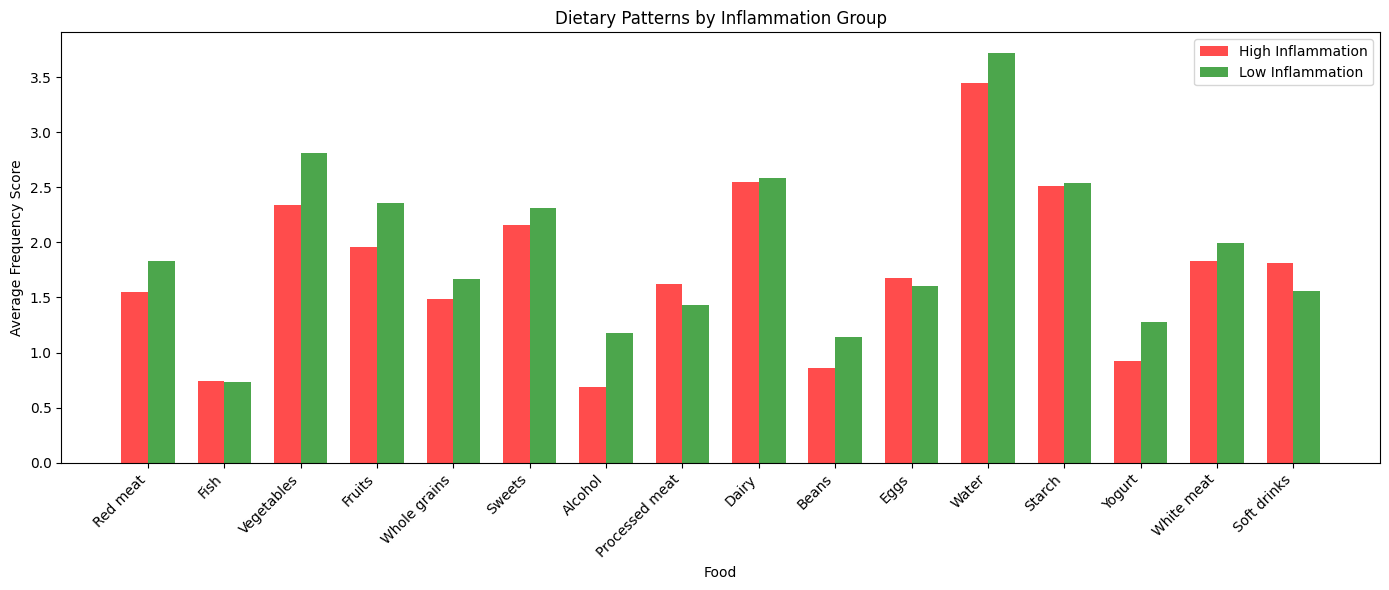

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 简化食物名字
food_short = ['Red meat', 'Fish', 'Vegetables', 'Fruits', 'Whole grains',
              'Sweets', 'Alcohol', 'Processed meat', 'Dairy', 'Beans',
              'Eggs', 'Water', 'Starch', 'Yogurt', 'White meat', 'Soft drinks']

x = np.arange(len(food_short))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, diet_by_inflammation.loc['High'], width, label='High Inflammation', color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, diet_by_inflammation.loc['Low'], width, label='Low Inflammation', color='green', alpha=0.7)

ax.set_xlabel('Food')
ax.set_ylabel('Average Frequency Score')
ax.set_title('Dietary Patterns by Inflammation Group')
ax.set_xticks(x)
ax.set_xticklabels(food_short, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

#NHANES

# download the dataset

In [ ]:
# ============================
# 1. Download NHANES 2009-2010 datasets
# ============================

import pandas as pd
import os

# Create folder
!mkdir -p NHANES_2009_2010

# Download files
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DEMO_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/DR1TOT_F.XPT
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/MCQ_F.XPT

# Check downloaded files
!ls NHANES_2009_2010

DEMO_F.XPT  DR1TOT_F.XPT  MCQ_F.XPT


# read the files

In [ ]:
# ============================
# 2. Read XPT files
# ============================

demo = pd.read_sas(
    "NHANES_2009_2010/DEMO_F.XPT"
)

diet = pd.read_sas(
    "NHANES_2009_2010/DR1TOT_F.XPT"
)

mcq = pd.read_sas(
    "NHANES_2009_2010/MCQ_F.XPT"
)


print("Demographics:", demo.shape)
print("Diet:", diet.shape)
print("MCQ:", mcq.shape)

Demographics: (10537, 43)
Diet: (10253, 166)
MCQ: (10109, 81)


In [ ]:
print(demo.columns.tolist())

print(diet.columns.tolist())

print(mcq.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIDEXMON', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDAGEEX', 'RIDRETH1', 'DMQMILIT', 'DMDBORN2', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDSCHOL', 'DMDMARTL', 'DMDHHSIZ', 'DMDFMSIZ', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR', 'RIDEXPRG', 'DMDHRGND', 'DMDHRAGE', 'DMDHRBR2', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANG', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA']
['SEQN', 'WTDRD1', 'WTDR2D', 'DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY', 'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z', 'DBD100', 'DRQSPREP', 'DRQSDIET', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT5', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DR1TNUMF', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TATOC', 'DR1TATOA', 'DR1TRET', 'DR1T

#Merge the files

In [ ]:
# ============================
# 3. Merge datasets
# ============================

nhanes = demo.merge(
    diet,
    on="SEQN",
    how="inner"
)

nhanes = nhanes.merge(
    mcq,
    on="SEQN",
    how="left"
)

print(nhanes.shape)

nhanes.head()

(10253, 288)


,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,...,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C
0,51624.0,6.0,2.0,1.0,1.0,34.0,409.0,410.0,3.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0
1,51625.0,6.0,2.0,2.0,1.0,4.0,49.0,50.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51626.0,6.0,2.0,1.0,1.0,16.0,202.0,202.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
3,51627.0,6.0,2.0,1.0,1.0,10.0,131.0,132.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
4,51628.0,6.0,2.0,2.0,2.0,60.0,722.0,722.0,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0


# Store the merged file

In [ ]:
nhanes.to_csv(
    "NHANES_2009_2010_merged.csv",
    index=False
)

print("Saved!")

Saved!


In [ ]:
df1 = pd.read_csv("NHANES_2009_2010_merged.csv")

In [ ]:
!wget -q -P NHANES_2009_2010 https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/CRP_F.XPT
crp = pd.read_sas(
    "NHANES_2009_2010/CRP_F.XPT"
)

df1 = df1.merge(
    crp,
    on="SEQN",
    how="left"
)

In [ ]:
df1.shape


(10253, 289)

# Distributino of CRP

In [ ]:
df1["LBXCRP"].describe()

,LBXCRP
count,8299.000000
mean,0.338788
std,0.713707
min,0.010000
25%,0.040000
50%,0.130000
75%,0.350000
max,18.010000


#Visualization of distribution of CRP

In [ ]:
crp_data = df1["LBXCRP"].dropna()

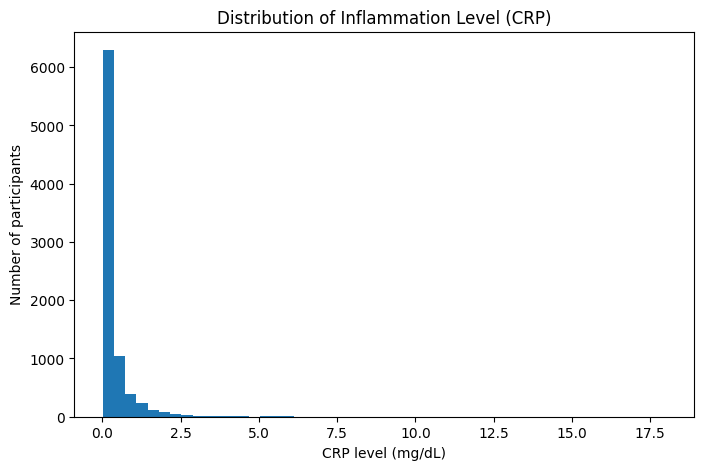

In [ ]:


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    crp_data,
    bins=50
)

plt.xlabel("CRP level (mg/dL)")
plt.ylabel("Number of participants")
plt.title("Distribution of Inflammation Level (CRP)")

plt.show()

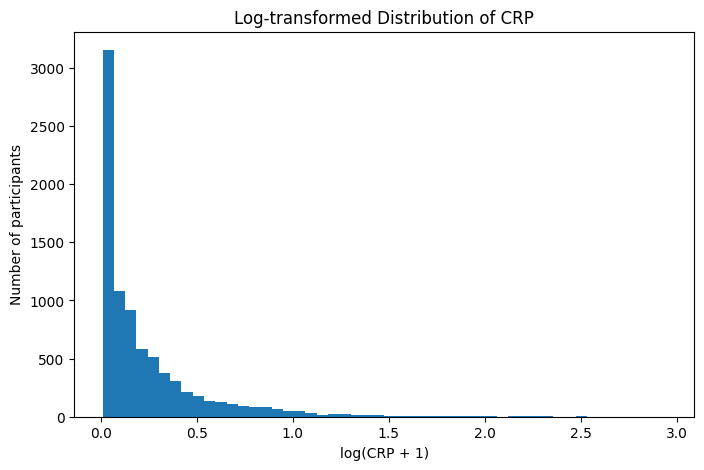

In [ ]:
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(crp_data),
    bins=50
)

plt.xlabel("log(CRP + 1)")
plt.ylabel("Number of participants")
plt.title("Log-transformed Distribution of CRP")

plt.show()

#Select the IBD patients from the dataset

In [ ]:
for col in [
    "MCQ160A",
    "MCQ160B",
    "MCQ160C",
    "MCQ160D",
    "MCQ160E",
    "MCQ160F",
    "MCQ160G",
    "MCQ160M",
    "MCQ160N"
]:
    print("="*30)
    print(col)
    print(df1[col].value_counts(dropna=False))

MCQ160A
MCQ160A
2.0    4402
NaN    4194
1.0    1641
9.0      16
Name: count, dtype: int64
MCQ160B
MCQ160B
2.0    5875
NaN    4194
1.0     167
9.0      17
Name: count, dtype: int64
MCQ160C
MCQ160C
2.0    5783
NaN    4194
1.0     250
9.0      26
Name: count, dtype: int64
MCQ160D
MCQ160D
2.0    5892
NaN    4194
1.0     151
9.0      16
Name: count, dtype: int64
MCQ160E
MCQ160E
2.0    5786
NaN    4194
1.0     258
9.0      15
Name: count, dtype: int64
MCQ160F
MCQ160F
2.0    5835
NaN    4194
1.0     218
9.0       6
Name: count, dtype: int64
MCQ160G
MCQ160G
2.0    5921
NaN    4194
1.0     135
9.0       3
Name: count, dtype: int64
MCQ160M
MCQ160M
2.0    5452
NaN    4194
1.0     595
9.0      12
Name: count, dtype: int64
MCQ160N
MCQ160N
2.0    5783
NaN    4194
1.0     271
9.0       5
Name: count, dtype: int64


In [ ]:
df1["IBD"] = (
    (df1["MCQ160E"] == 1) |
    (df1["MCQ160F"] == 1)
).astype(int)

print(df1["IBD"].value_counts())

IBD
0    9825
1     428
Name: count, dtype: int64


In [ ]:
# ============================
# 1. Create IBD sample
# ============================

ibd_sample = df1[df1["IBD"] == 1].copy()

print("IBD sample size:", ibd_sample.shape)


# ============================
# 2. Select dietary variables
# ============================

diet_vars = [
    "DR1TKCAL",   # Total calories
    "DR1TPROT",   # Protein
    "DR1TCARB",   # Carbohydrate
    "DR1TSUGR",   # Sugar
    "DR1TFIBE",   # Fiber
    "DR1TTFAT",   # Total fat
    "DR1TSFAT",   # Saturated fat
    "DR1TMFAT",   # Monounsaturated fat
    "DR1TPFAT",   # Polyunsaturated fat
    "DR1TCHOL",   # Cholesterol
    "DR1TVC",     # Vitamin C
    "DR1TVE",     # Vitamin E
    "DR1TVK",     # Vitamin K
    "DR1TCALC",   # Calcium
    "DR1TIRON",   # Iron
    "DR1TZINC",   # Zinc
    "DR1TALCO"    # Alcohol
]


# Check which variables exist
available_diet_vars = [
    var for var in diet_vars
    if var in ibd_sample.columns
]

print("Available diet variables:")
print(available_diet_vars)


# ============================
# 3. Spearman correlation:
# Diet intake vs CRP
# ============================

from scipy.stats import spearmanr
import pandas as pd


results = []

for var in available_diet_vars:

    temp = ibd_sample[[var, "LBXCRP"]].dropna()

    rho, p = spearmanr(
        temp[var],
        temp["LBXCRP"]
    )

    results.append({
        "Diet variable": var,
        "Spearman rho": rho,
        "p-value": p,
        "Sample size": len(temp)
    })


spearman_results = pd.DataFrame(results)


# Sort by p-value
spearman_results = spearman_results.sort_values(
    by="p-value"
)


spearman_results

IBD sample size: (428, 290)
Available diet variables:
['DR1TKCAL', 'DR1TPROT', 'DR1TCARB', 'DR1TSUGR', 'DR1TFIBE', 'DR1TTFAT', 'DR1TSFAT', 'DR1TMFAT', 'DR1TPFAT', 'DR1TCHOL', 'DR1TVC', 'DR1TVK', 'DR1TCALC', 'DR1TIRON', 'DR1TZINC', 'DR1TALCO']


,Diet variable,Spearman rho,p-value,Sample size
4,DR1TFIBE,-0.150234,0.003329,380
13,DR1TIRON,-0.129816,0.011310,380
14,DR1TZINC,-0.112955,0.027688,380
15,DR1TALCO,-0.099537,0.052530,380
10,DR1TVC,-0.093019,0.070107,380
12,DR1TCALC,-0.089432,0.081666,380
0,DR1TKCAL,-0.084220,0.101161,380
6,DR1TSFAT,-0.068403,0.183323,380
5,DR1TTFAT,-0.065485,0.202773,380
2,DR1TCARB,-0.063510,0.216756,380


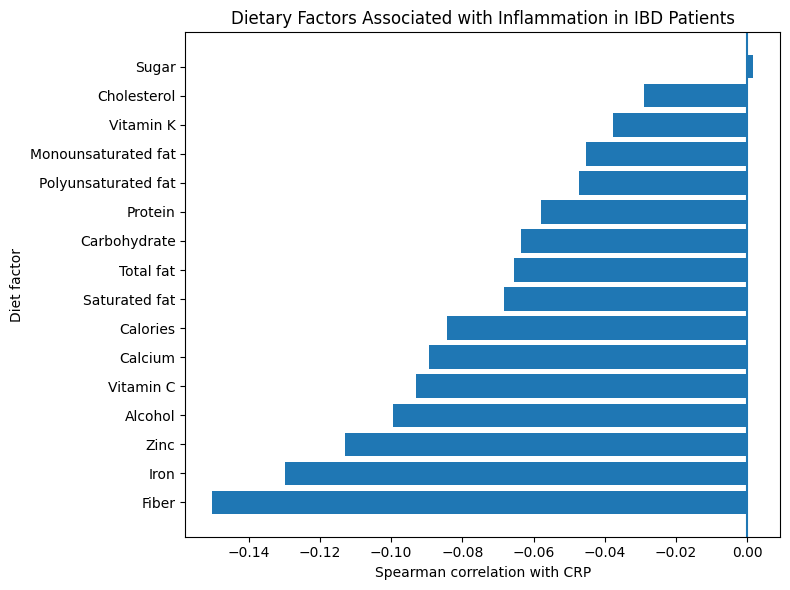

In [ ]:
# Rename diet variables for visualization

diet_labels = {
    "DR1TKCAL": "Calories",
    "DR1TPROT": "Protein",
    "DR1TCARB": "Carbohydrate",
    "DR1TSUGR": "Sugar",
    "DR1TFIBE": "Fiber",
    "DR1TTFAT": "Total fat",
    "DR1TSFAT": "Saturated fat",
    "DR1TMFAT": "Monounsaturated fat",
    "DR1TPFAT": "Polyunsaturated fat",
    "DR1TCHOL": "Cholesterol",
    "DR1TVC": "Vitamin C",
    "DR1TVK": "Vitamin K",
    "DR1TCALC": "Calcium",
    "DR1TIRON": "Iron",
    "DR1TZINC": "Zinc",
    "DR1TALCO": "Alcohol"
}


plot_df = spearman_results.copy()

plot_df["Diet"] = plot_df["Diet variable"].map(diet_labels)

plot_df = plot_df.sort_values(
    "Spearman rho"
)
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))

plt.barh(
    plot_df["Diet"],
    plot_df["Spearman rho"]
)

plt.axvline(0)

plt.xlabel("Spearman correlation with CRP")
plt.ylabel("Diet factor")

plt.title(
    "Dietary Factors Associated with Inflammation in IBD Patients"
)

plt.tight_layout()
plt.show()

In [ ]:
ibd_sample["LBXCRP"].describe()

,LBXCRP
count,401.000000
mean,0.537431
std,0.879719
min,0.010000
25%,0.100000
50%,0.240000
75%,0.620000
max,11.320000


In [ ]:
# Create CRP tertile groups

ibd_sample_crp = ibd_sample.dropna(
    subset=["LBXCRP"]
).copy()


ibd_sample_crp["CRP_group"] = pd.qcut(
    ibd_sample_crp["LBXCRP"],
    q=3,
    labels=[
        "Low inflammation",
        "Medium inflammation",
        "High inflammation"
    ]
)


print(
    ibd_sample_crp["CRP_group"].value_counts()
)


print(
    ibd_sample_crp.groupby(
        "CRP_group"
    )["LBXCRP"].describe()
)

CRP_group
Low inflammation       136
High inflammation      133
Medium inflammation    132
Name: count, dtype: int64
                     count      mean       std   min     25%   50%     75%  \
CRP_group                                                                    
Low inflammation     136.0  0.073603  0.035563  0.01  0.0500  0.07  0.1000   
Medium inflammation  132.0  0.261288  0.089018  0.15  0.1875  0.24  0.3225   
High inflammation    133.0  1.285789  1.214008  0.46  0.6300  0.94  1.5800   

                       max  
CRP_group                   
Low inflammation      0.14  
Medium inflammation   0.45  
High inflammation    11.32  


/tmp/ipykernel_4277/2515554683.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ibd_sample_crp.groupby(


In [ ]:
diet_compare = (
    ibd_sample_crp
    .groupby("CRP_group", observed=False)[
        ["DR1TFIBE", "DR1TIRON", "DR1TZINC"]
    ]
    .mean()
)

diet_compare
import matplotlib.pyplot as plt


# Calculate mean intake by CRP group
diet_compare = (
    ibd_sample_crp
    .groupby("CRP_group", observed=False)[
        ["DR1TFIBE", "DR1TIRON", "DR1TZINC"]
    ]
    .mean()
)


# Rename variables for display
diet_compare = diet_compare.rename(
    columns={
        "DR1TFIBE": "Fiber",
        "DR1TIRON": "Iron",
        "DR1TZINC": "Zinc"
    }
)

diet_compare

,Fiber,Iron,Zinc
CRP_group,,,
Low inflammation,16.806977,15.651783,11.712248
Medium inflammation,15.195161,13.623790,11.062500
High inflammation,13.656693,12.918740,9.831024


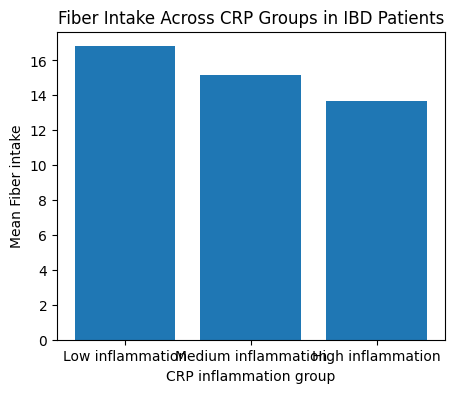

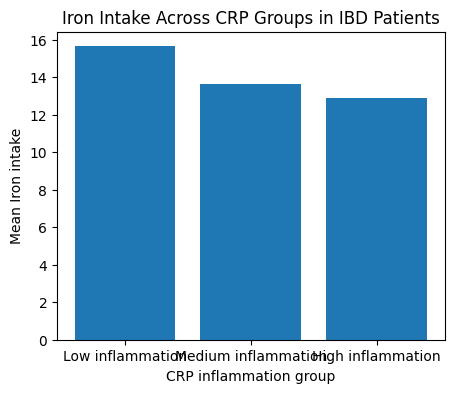

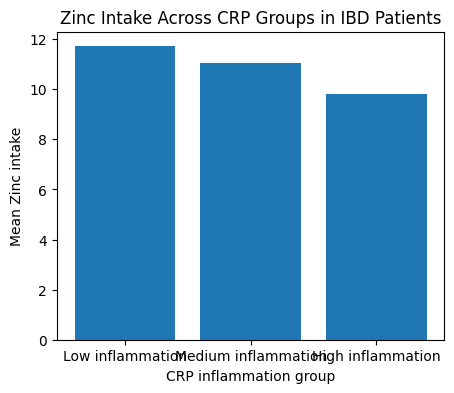

In [ ]:
import matplotlib.pyplot as plt


for nutrient in diet_compare.columns:

    plt.figure(figsize=(5,4))

    plt.bar(
        diet_compare.index,
        diet_compare[nutrient]
    )

    plt.xlabel("CRP inflammation group")
    plt.ylabel(f"Mean {nutrient} intake")

    plt.title(
        f"{nutrient} Intake Across CRP Groups in IBD Patients"
    )

    plt.xticks(rotation=0)

    plt.show()